In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



📥 Loading dataset...
✂️ Splitting data...
🌳 Training Random Forest model...

📊 Evaluating model...

✅ Accuracy: 0.9649

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


🔬 Analyzing feature importance...

🔥 Top 10 Important Features:

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


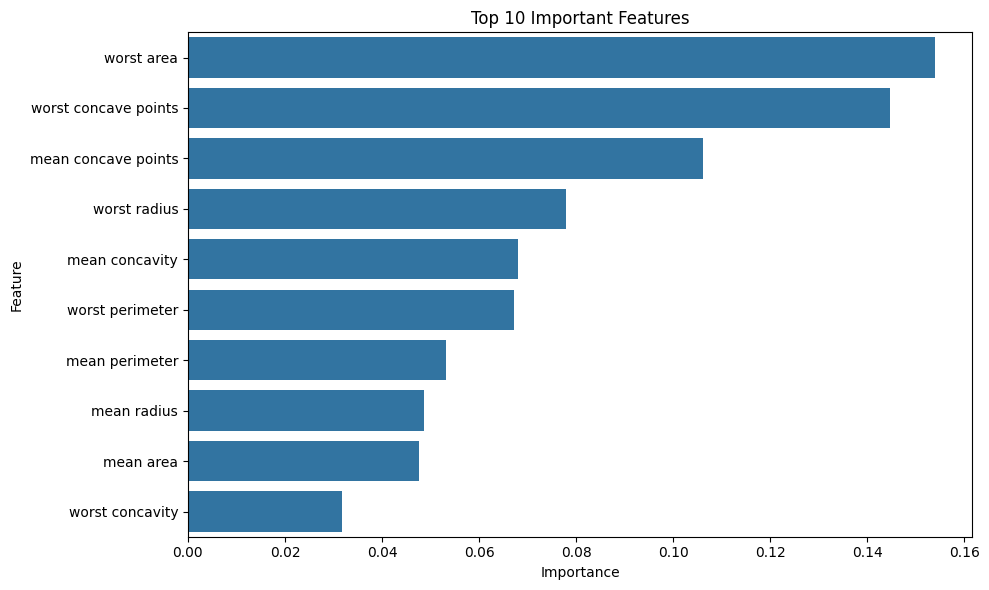


💾 Model saved as 'tumor_model.pkl'

🧪 Testing prediction with a sample...

Prediction Result: 🟢 Benign (Non-Cancerous)

🚀 Script completed successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("\n📥 Loading dataset...")
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

#Define Features and Target
X = df.drop('target', axis=1)
y = df['target']

#Train-Test Split
print("✂️ Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Build Model
print("🌳 Training Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Evaluate Model
print("\n📊 Evaluating model...")
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f}")
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred))

#Feature Importance
print("\n🔬 Analyzing feature importance...")

importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n🔥 Top 10 Important Features:\n")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

#Save Model
joblib.dump(model, 'tumor_model.pkl')
print("\n💾 Model saved as 'tumor_model.pkl'")

# Prediction Function
def predict_tumor(sample_data):
    prediction = model.predict([sample_data])
    
    if prediction[0] == 0:
        return "🔴 Malignant (Cancerous)"
    else:
        return "🟢 Benign (Non-Cancerous)"
# Test Prediction with Example
print("\n🧪 Testing prediction with a sample...")

sample = X_test.iloc[0].values
result = predict_tumor(sample)

print("\nPrediction Result:", result)

# Optional User Input Mode
def user_input_prediction():
    print("\n🧾 Enter values for prediction:")

    input_data = []
    for feature in X.columns:
        val = float(input(f"{feature}: "))
        input_data.append(val)

    result = predict_tumor(input_data)
    print("\n🧠 Model Prediction:", result)

# Uncomment below to enable manual input mode
# user_input_prediction()

print("\n🚀 Script completed successfully!")